In [1]:
import os

import torch
import tensorkrowch as tk
import matplotlib.pyplot as plt

from utils import *

from sklearn.model_selection import RepeatedKFold

## Train LR model

In [2]:
cwd = os.path.join(os.getcwd(), '..')

model_name = 'llr6'
n_classes = 2

In [ ]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'MinMax'
scaler_type = 'Standard'

dataset = ['Chowell_train']
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

dataset = ['Chowell_test']
data_test, scalers_test = load_data(cwd,
                                    featuresNA,
                                    phenoNA,
                                    dataset,
                                    scaler_type)

In [ ]:
data_train

In [5]:
# Train vanilla model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

print('\n* TRAINING MODEL:')
loris_van = train_model(model_name, 'vanilla', x_train, y_train, x_test, y_test)


* TRAINING MODEL:
Model accuracy: Train: 0.69, Test: 0.72
Model balanced accuracy: Train: 0.68, Test: 0.69
Correct predicitons
Train:
Class 0: 486 / 682 (0.7126)
Class 1: 182 / 282 (0.6454)
Test:
Class 0: 288 / 388 (0.7423)
Class 1: 82 / 127 (0.6457)



In [6]:
loris_van.coef_

array([[ 0.43363393,  0.25947541, -0.16895724,  0.07917599, -0.41626903,
        -0.09484781, -0.0443376 , -0.01898716,  0.        ,  0.09820122,
         0.06018146,  0.01449584, -0.02354492,  0.        ,  0.01722608,
         0.        ,  0.        , -0.16897053,  0.15901237,  0.00392403,
         0.        ]])

In [7]:
loris_van.intercept_

array([-0.13433263])

In [8]:
loris_van.predict_proba(torch.zeros(5, 21))

array([[0.53353275, 0.46646725],
       [0.53353275, 0.46646725],
       [0.53353275, 0.46646725],
       [0.53353275, 0.46646725],
       [0.53353275, 0.46646725]])

In [9]:
# Train average model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

print('\n* TRAINING MODEL:')
loris_avg = train_model(model_name, 'average', x_train, y_train, x_test, y_test)


* TRAINING MODEL:
Model accuracy: Train: 0.69, Test: 0.73
Model balanced accuracy: Train: 0.68, Test: 0.69
Correct predicitons
Train:
Class 0: 489 / 682 (0.7170)
Class 1: 180 / 282 (0.6383)
Test:
Class 0: 294 / 388 (0.7577)
Class 1: 80 / 127 (0.6299)



## Tensorize

In [ ]:
# Tensorize model
# ---------------
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

# sketch_size could be chosen smaller, e.g., sketch_size = 50, and the
# tensorization will be much faster returning a tt_model with the same accuracy,
# but sometimes this could lead to having negative values for inputs with low
# probability. Choosing a bigger sketch_size usually avoids these errors.
sketch_size    = 200
phys_dim       = 2
domain         = torch.linspace(0, 1, phys_dim)
bond_dim       = 2
cum_percentage = 1 - 1e-5
batch_size     = 500
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


# def fn_model(data):
#     result = torch.from_numpy(loris_van.predict_proba(data)).float()
#     return result

# def fn_model(data):
#     result = torch.from_numpy(loris_van.predict_proba(data)).float().sqrt()
#     return result

# def fn_model(data):
#     y_proba = loris_van.predict_proba(data)
#     y_pred = (y_proba > 0.5)
#     result = torch.from_numpy(y_pred).float()
#     return result

def fn_model(data, n_bins=6):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()

    # Bin width
    step = 1.0 / n_bins

    # Compute bin index
    bin_idx = torch.floor(y_proba / step)  # 0 .. n_bins-1

    # Lower & upper edges of the bin
    bin_low  = bin_idx * step
    bin_high = bin_low + step

    # Apply your rule:
    #   if prob <= 0.5 → snap to lower edge
    #   if prob > 0.5  → snap to upper edge
    result = torch.where(y_proba <= 0.5, bin_low, bin_high)

    # Clip to [0,1]
    result = torch.clamp(result, 0.0, 1.0)

    return result.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


print('* TENSORIZING MODEL:')
mps = tensorize(fn_model=fn_model,
                embedding=embedding,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

In [10]:
dataset = datasets
data_sketch, scalers_sketch = load_sketch_data(cwd,
                                               featuresNA,
                                               phenoNA,
                                               dataset,
                                               scaler_type,
                                               n_samples=10)

x_sketch = data_sketch[featuresNA].values
y_sketch = data_sketch[phenoNA].values

print(x_sketch.shape)

(297, 21)


In [11]:
# Tensorize model
# ---------------
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

xt_sketch = torch.from_numpy(x_sketch).float()
yt_sketch = torch.from_numpy(y_sketch)

# sketch_size could be chosen smaller, e.g., sketch_size = 50, and the
# tensorization will be much faster returning a tt_model with the same accuracy,
# but sometimes this could lead to having negative values for inputs with low
# probability. Choosing a bigger sketch_size usually avoids these errors.
sketch_size    = 50
phys_dim       = 2
domain         = None #torch.linspace(0, 1, phys_dim)
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


# def fn_model(data):
#     result = torch.from_numpy(loris_van.predict_proba(data)).float()
#     return result

# def fn_model(data):
#     result = torch.from_numpy(loris_van.predict_proba(data)).float().sqrt()
#     return result

# def fn_model(data):
#     y_proba = loris_van.predict_proba(data)
#     y_pred = (y_proba > 0.5)
#     result = torch.from_numpy(y_pred).float()
#     return result

def fn_model(data, n_bins=6):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()

    # Bin width
    step = 1.0 / n_bins

    # Compute bin index
    bin_idx = torch.floor(y_proba / step)  # 0 ... n_bins-1

    # Lower & upper edges of the bin
    bin_low  = bin_idx * step
    bin_high = bin_low + step

    # Apply your rule:
    #   if prob <= 0.5 → snap to lower edge
    #   if prob > 0.5  → snap to upper edge
    result = torch.where(y_proba <= 0.5, bin_low, bin_high)

    # Clip to [0,1]
    result = torch.clamp(result, 0.0, 1.0)

    return result.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


print('* TENSORIZING MODEL:')
mps,_,_ = tensorize(fn_model=fn_model,
                embedding=embedding,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                x_sketch=xt_train,
                y_sketch=yt_train,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

* TENSORIZING MODEL:
Info: {'total_time': 1.9379479885101318, 'val_eps': tensor(0.1525)}

MSE: Sketch: 9.22e-02, Train: 0.092, Test: 9.02e-02
tensor([[0.8490, 0.5661],
        [0.7246, 0.6191],
        [0.7416, 0.5805],
        [0.7561, 0.6120],
        [1.0192, 0.1050],
        [0.7950, 0.5824],
        [0.6929, 0.7518],
        [0.8575, 0.5806],
        [0.8018, 0.5745],
        [0.5320, 0.8677]])
tensor([[0.9129, 0.4082],
        [0.5774, 0.8165],
        [0.5774, 0.8165],
        [0.8165, 0.5774],
        [1.0000, 0.0000],
        [0.8165, 0.5774],
        [0.5774, 0.8165],
        [0.9129, 0.4082],
        [0.8165, 0.5774],
        [0.5774, 0.8165]])
tensor([0, 0, 1, 0, 0, 1, 1, 0, 1, 1])

Sketch accuracies:
Model accuracy: TT: 0.68, LR: 0.69
Model balanced accuracy: TT: 0.66, LR: 0.68

Train/test TT accuracies:
Model accuracy: Train: 0.68, Test: 0.71
Model balanced accuracy: Train: 0.66, Test: 0.66

Correct predicitons:
Train:
Class 0: 487 / 682 (0.7141)
Class 1: 169 / 282 (0.599

In [17]:
sketch_size    = 50
phys_dim       = 2
domain         = None #torch.linspace(0, 1, phys_dim)
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False

train_baccs = []
test_baccs = []

kf = RepeatedKFold(n_splits=5,
                   n_repeats=100)

# Store results
for i, (train_idx, _) in enumerate(kf.split(x_train)):
    xt_train_aux = xt_train[train_idx]
    yt_train_aux = yt_train[train_idx]
    
    loris_van = train_model(model_name, 'vanilla',
                            xt_train_aux, yt_train_aux,
                            xt_test, yt_test)
    
    # loris_van = rescale_lr_models(loris_van, scalers_train, featuresNA)
    
    def fn_model(data, n_bins=6):
        # Get probabilities (numpy)
        y_proba = loris_van.predict_proba(data)
        y_proba = torch.from_numpy(y_proba).float()

        # Bin width
        step = 1.0 / n_bins

        # Compute bin index
        bin_idx = torch.floor(y_proba / step)  # 0 ... n_bins-1

        # Lower & upper edges of the bin
        bin_low  = bin_idx * step
        bin_high = bin_low + step

        # Apply your rule:
        #   if prob <= 0.5 → snap to lower edge
        #   if prob > 0.5  → snap to upper edge
        result = torch.where(y_proba <= 0.5, bin_low, bin_high)

        # Clip to [0,1]
        result = torch.clamp(result, 0.0, 1.0)

        return result.sqrt()
    
    mps, train_bacc, test_bacc = tensorize(fn_model=fn_model,
                                            embedding=embedding,
                                            x_train=xt_train_aux,
                                            y_train=yt_train_aux,
                                            x_test=xt_test,
                                            y_test=yt_test,
                                            x_sketch=xt_train_aux,
                                            y_sketch=yt_train_aux,
                                            sketch_size=sketch_size,
                                            phys_dim=phys_dim,
                                            domain=domain,
                                            bond_dim=bond_dim,
                                            cum_percentage=cum_percentage,
                                            batch_size=batch_size,
                                            device=device,
                                            dtype=dtype,
                                            verbose=False)
    
    train_baccs.append(train_bacc)
    test_baccs.append(test_bacc)
    
    print(i)

train_baccs = torch.stack([torch.tensor(float(el)) for el in train_baccs])
test_baccs = torch.stack([torch.tensor(float(el)) for el in test_baccs])

Model accuracy: Train: 0.70, Test: 0.71
Model balanced accuracy: Train: 0.68, Test: 0.69
Correct predicitons
Train:
Class 0: 392 / 539 (0.7273)
Class 1: 148 / 232 (0.6379)
Test:
Class 0: 284 / 388 (0.7320)
Class 1: 83 / 127 (0.6535)

Info: {'total_time': 1.917956829071045, 'val_eps': tensor(0.5289)}

MSE: Sketch: 3.02e-01, Train: 0.3, Test: 2.70e-01
tensor([[ 0.7954,  0.6140],
        [ 0.8345,  0.5763],
        [ 0.8401,  0.5103],
        [ 0.8814,  0.4401],
        [ 0.6121,  0.7468],
        [ 0.5988,  0.9838],
        [ 0.9908,  0.1024],
        [ 0.4437,  0.9025],
        [ 0.7881,  1.0600],
        [ 0.9895, -0.3956]])
tensor([[0.8165, 0.5774],
        [0.8165, 0.5774],
        [0.8165, 0.5774],
        [0.9129, 0.4082],
        [0.5774, 0.8165],
        [0.5774, 0.8165],
        [1.0000, 0.0000],
        [0.4082, 0.9129],
        [0.9129, 0.4082],
        [0.8165, 0.5774]])
tensor([0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

Sketch accuracies:
Model accuracy: TT: 0.64, LR: 0.70
Model balanc

In [18]:
# train_baccs = torch.stack([torch.tensor(float(el)) for el in train_baccs])
# test_baccs = torch.stack([torch.tensor(float(el)) for el in test_baccs])

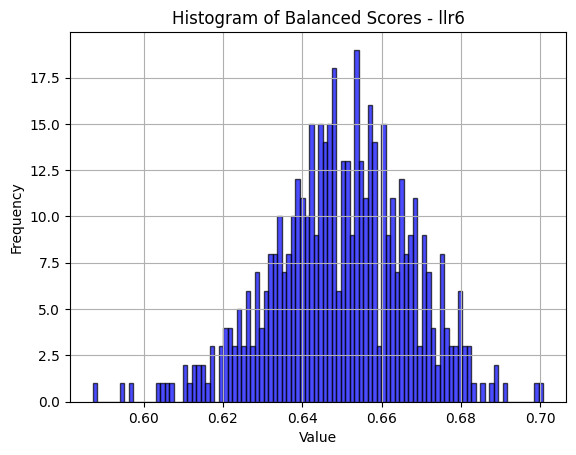

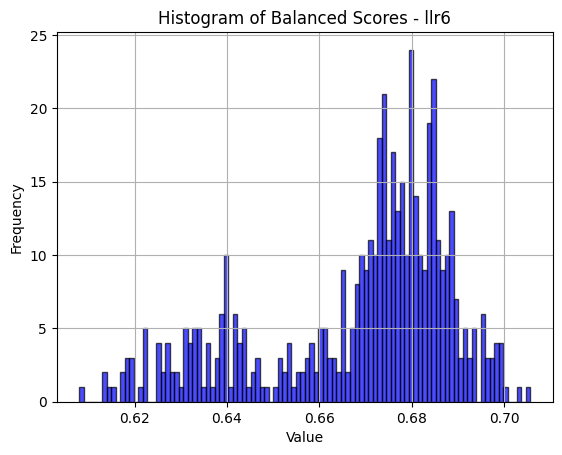

In [19]:
plt.hist(train_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

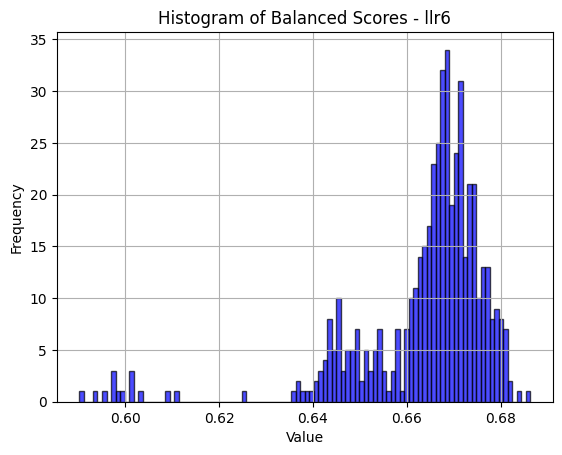

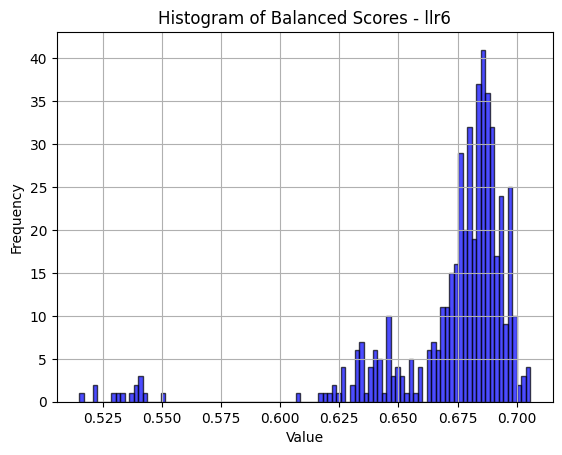

In [ ]:
plt.hist(train_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

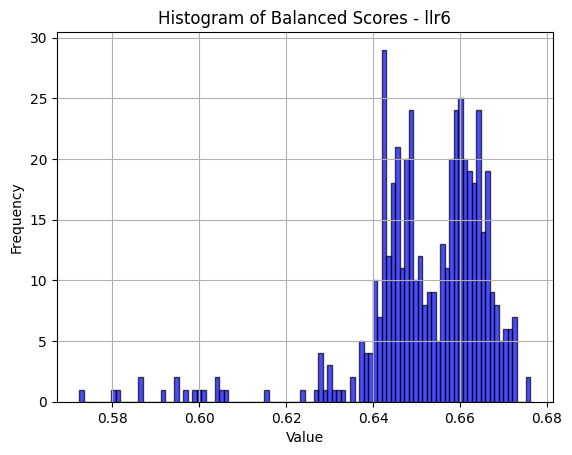

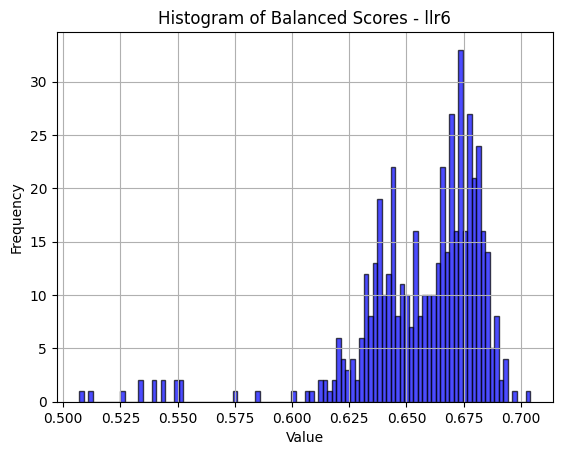

In [ ]:
plt.hist(train_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

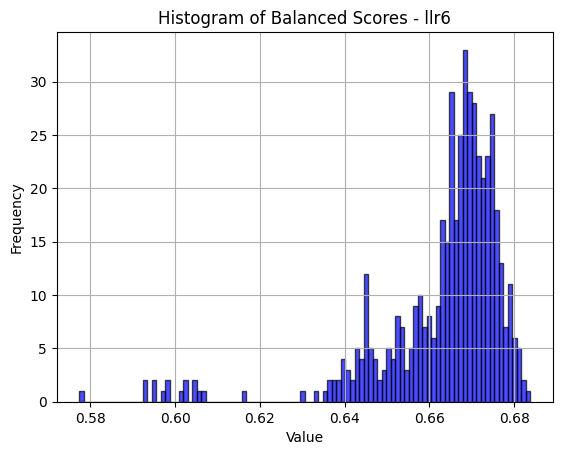

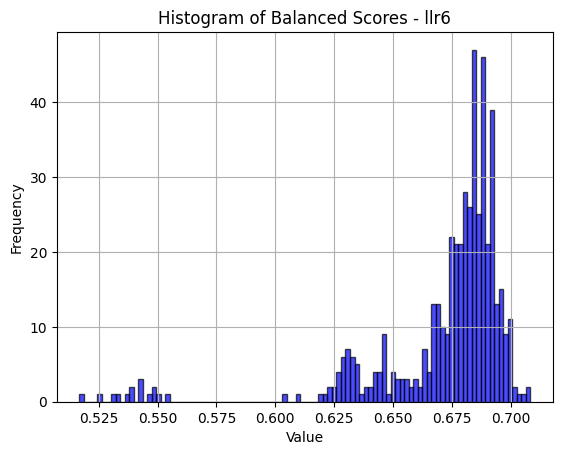

In [ ]:
plt.hist(train_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

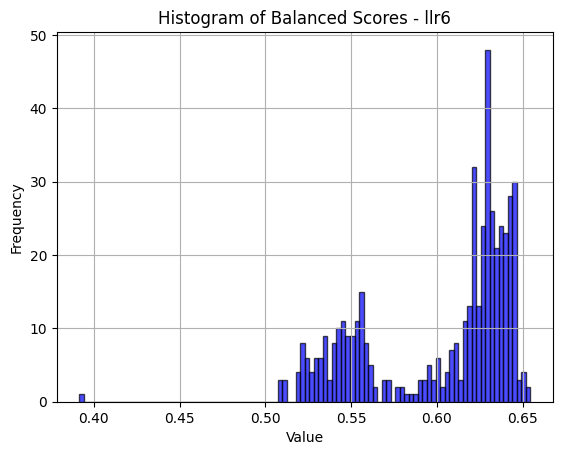

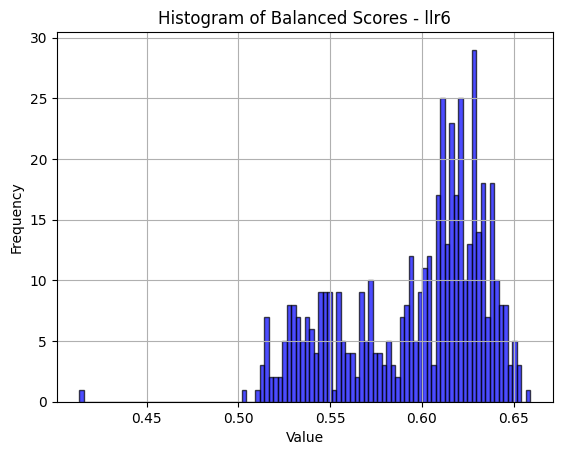

In [ ]:
plt.hist(train_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

In [ ]:
sketch_size    = 100
phys_dim       = 2
domain         = None #torch.linspace(0, 1, phys_dim)
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False

train_lr_baccs = []
test_lr_baccs = []

train_tt_baccs = []
test_tt_baccs = []

kf = RepeatedKFold(n_splits=5,
                   n_repeats=100)

# Store results
for i, (train_idx, test_idx) in enumerate(kf.split(x_train)):
    xt_train_aux = xt_train[train_idx]
    yt_train_aux = yt_train[train_idx]
    xt_test_aux = xt_train[test_idx]
    yt_test_aux = yt_train[test_idx]
    
    loris_van, train_bacc, test_bacc = train_lr_model('vanilla',
                                                      xt_train_aux, yt_train_aux,
                                                      xt_test_aux, yt_test_aux)
    train_lr_baccs.append(train_bacc)
    test_lr_baccs.append(test_bacc)
    
    # loris_van = rescale_lr_models(loris_van, scalers_train, featuresNA)
    
    def fn_model(data, n_bins=6):
        # Get probabilities (numpy)
        y_proba = loris_van.predict_proba(data)
        y_proba = torch.from_numpy(y_proba).float()

        # Bin width
        step = 1.0 / n_bins

        # Compute bin index
        bin_idx = torch.floor(y_proba / step)  # 0 ... n_bins-1

        # Lower & upper edges of the bin
        bin_low  = bin_idx * step
        bin_high = bin_low + step

        # Apply your rule:
        #   if prob <= 0.5 → snap to lower edge
        #   if prob > 0.5  → snap to upper edge
        result = torch.where(y_proba <= 0.5, bin_low, bin_high)

        # Clip to [0,1]
        result = torch.clamp(result, 0.0, 1.0)

        return result.sqrt()
    
    mps, train_bacc, test_bacc = tensorize(fn_model=fn_model,
                                            embedding=embedding,
                                            x_train=xt_train_aux,
                                            y_train=yt_train_aux,
                                            x_test=xt_test_aux,
                                            y_test=yt_test_aux,
                                            x_sketch=xt_train_aux,
                                            y_sketch=yt_train_aux,
                                            sketch_size=sketch_size,
                                            phys_dim=phys_dim,
                                            domain=domain,
                                            bond_dim=bond_dim,
                                            cum_percentage=cum_percentage,
                                            batch_size=batch_size,
                                            device=device,
                                            dtype=dtype,
                                            verbose=False)
    
    train_tt_baccs.append(train_bacc)
    test_tt_baccs.append(test_bacc)
    
    print(i)

train_lr_baccs = torch.stack([torch.tensor(float(el)) for el in train_lr_baccs])
test_lr_baccs = torch.stack([torch.tensor(float(el)) for el in test_lr_baccs])

train_tt_baccs = torch.stack([torch.tensor(float(el)) for el in train_tt_baccs])
test_tt_baccs = torch.stack([torch.tensor(float(el)) for el in test_tt_baccs])

*TRAINING MODEL*

Accuracy: Train: 0.68, Test: 0.73
Balanced accuracy: Train: 0.66, Test: 0.73

*Correct predicitons*
Train:
    Class 0: 378 / 540 (0.7000)
    Class 1: 145 / 231 (0.6277)
Test:
    Class 0: 102 / 142 (0.7183)
    Class 1: 38 / 51 (0.7451)

*TENSORIZING MODEL*

Info: {'total_time': 2.937566041946411, 'val_eps': tensor(0.0837)}

MSE: Sketch: 1.92e-02, Train: 0.019, Test: 2.32e-02
tensor([[0.9707, 0.2791],
        [0.9309, 0.3594],
        [0.5621, 0.8323],
        [0.7430, 0.6689],
        [0.6397, 0.7907],
        [0.7614, 0.6037],
        [0.7762, 0.6473],
        [0.7694, 0.6843],
        [0.6667, 0.7183],
        [0.6012, 0.7635]])
tensor([[0.9129, 0.4082],
        [0.9129, 0.4082],
        [0.5774, 0.8165],
        [0.8165, 0.5774],
        [0.5774, 0.8165],
        [0.8165, 0.5774],
        [0.8165, 0.5774],
        [0.8165, 0.5774],
        [0.5774, 0.8165],
        [0.5774, 0.8165]])
tensor([0, 1, 1, 0, 0, 0, 0, 0, 1, 1])

*Sketch accuracies*
Accuracy: TT: 0.66,

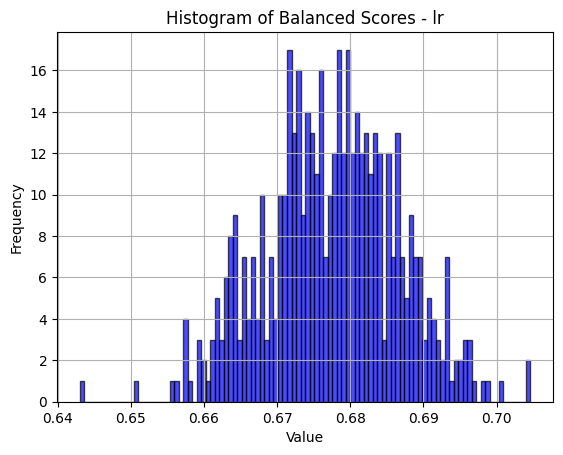

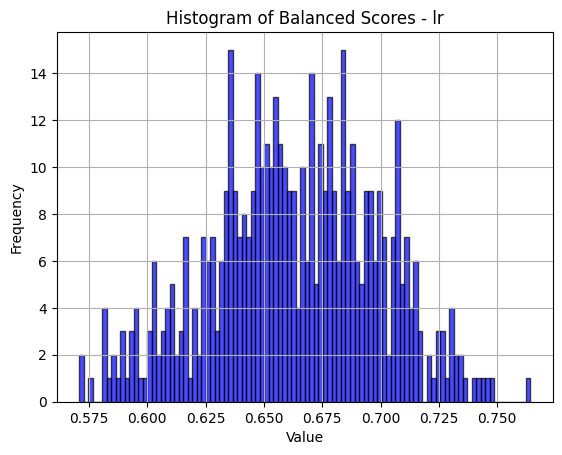

In [ ]:
# 100 sketch samples

plt.hist(train_lr_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_lr_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

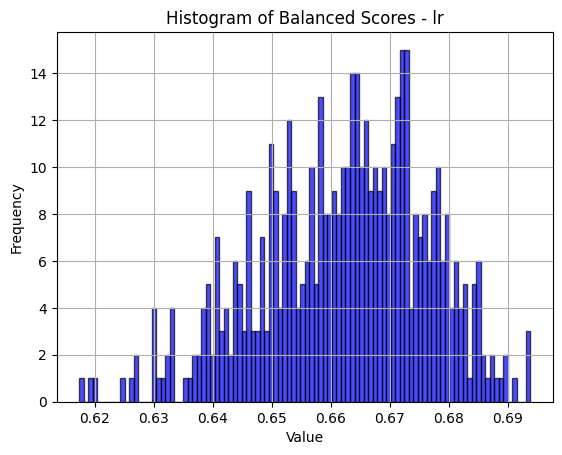

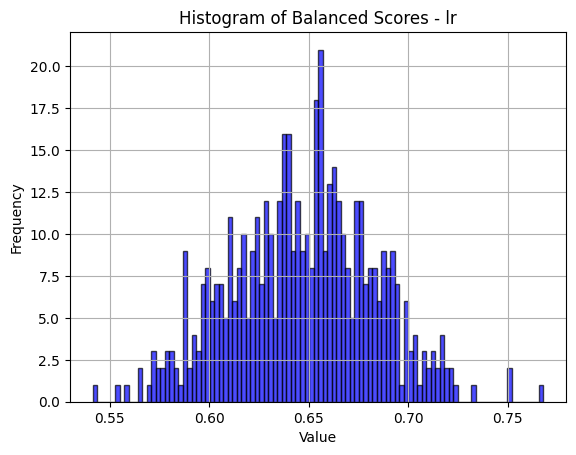

In [ ]:
plt.hist(train_tt_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_tt_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

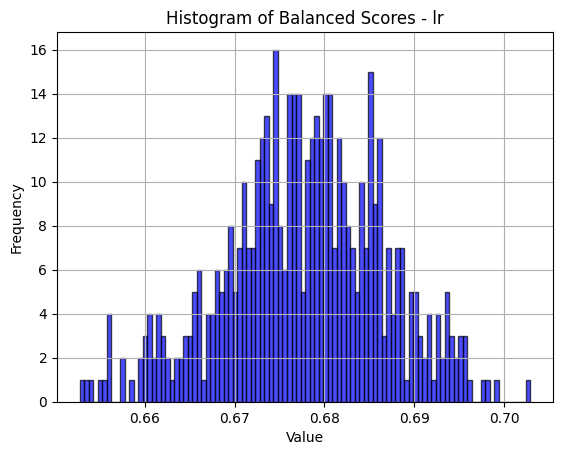

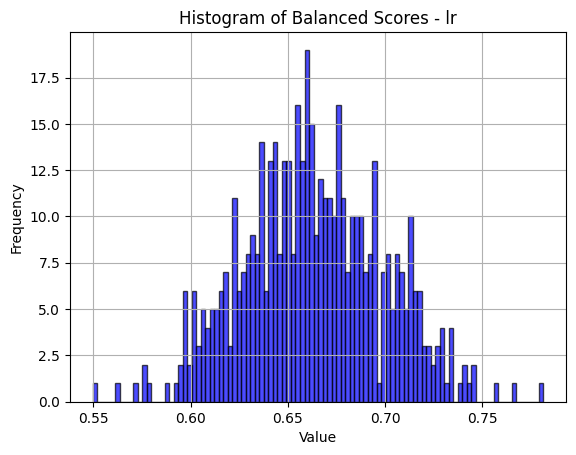

In [ ]:
# 50 sketch samples

plt.hist(train_lr_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_lr_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

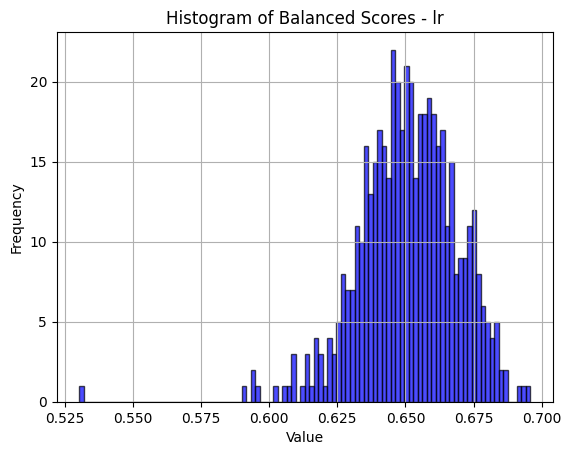

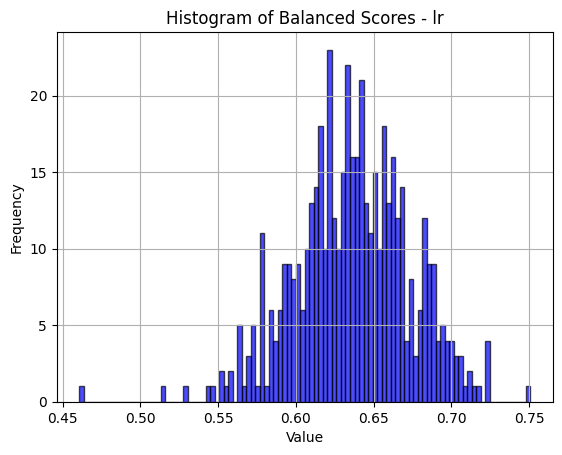

In [ ]:
plt.hist(train_tt_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()


plt.hist(test_tt_baccs.numpy(), bins=100, alpha=0.7,
            color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title(f"Histogram of Balanced Scores - {model_name}")
plt.grid(True)

# Show plot
plt.show()

### Explore re-training

In [ ]:
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    return mps(embedding(data)).pow(2)

n_num = len(numeric_featuresNA)
n_cat = mps.n_features - n_num - 1
n_features = mps.n_features

In [ ]:
n_num = len(numeric_featuresNA)
n_cat = mps.n_features - n_num - 1
n_features = mps.n_features

# For first 4 continuous variables
emb_input_cont = []
for i in range(n_num):
    aux_domain = torch.linspace(xt_train[:, i].min(),
                                xt_train[:, i].max(),
                                discr_steps).unsqueeze(1)
    aux_emb_input_cont = embedding(aux_domain).squeeze(1)
    aux_emb_input_cont = aux_emb_input_cont.sum(dim=0, keepdim=True) / discr_steps
    emb_input_cont.append(aux_emb_input_cont)

# For next 17 discrete variables
aux_domain = torch.arange(phys_dim).unsqueeze(1)
emb_input_discr = embedding(aux_domain).squeeze(1)
emb_input_discr = emb_input_discr.sum(dim=0, keepdim=True)

# For output variable
emb_input_out = torch.ones(1, n_classes)

# All features
emb_input = emb_input_cont + [emb_input_discr.clone() for _ in range(n_cat)]
emb_input = emb_input[:(n_features // 2)] + [emb_input_out] + \
            emb_input[(n_features // 2):]
emb_input = torch.stack(emb_input, dim=1)

# Compute norm
mps.reset()
mps.unset_data_nodes()
mps.out_features = []

mps_norm = mps(emb_input)
mps_norm

tensor([1.0000], grad_fn=<ViewBackward0>)

In [ ]:
aux_xt_train = embedding(xt_train)
aux_yt_train = tk.embeddings.basis(yt_train, dim=n_classes).unsqueeze(1)
data_train = torch.cat([aux_xt_train[:, :(n_features // 2)],
                        aux_yt_train,
                        aux_xt_train[:, (n_features // 2):]], dim=1)

dataset = TensorDataset(data_train)
dataloader = DataLoader(dataset, batch_size=1000, shuffle=True)

learning_rate = 1e-2
alpha = 1

def criterion(probs):
    return -probs.log().sum()

optimizer = optim.SGD(mps.parameters(), lr=learning_rate)

num_epochs = 1000

for epoch in range(num_epochs):
    
    running_loss = 0.0
    
    for aux_x in dataloader:
        aux_x = aux_x[0]
        probs = mps(aux_x).pow(2)
        loss = criterion(probs)
        # mps_norm = mps(emb_input)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Loss = {loss:.4f}")
        
        # total_loss = (1. - mps_norm).pow(2) * alpha + loss
        total_loss = loss
        # print(total_loss)
        
        optimizer.zero_grad()
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * aux_x.size(0)
        
    avg_loss = running_loss / len(dataset)

    if (epoch + 1) % 10 == 0:
        # print(f"Epoch {epoch+1}/{num_epochs}, Loss = {avg_loss:.4f}, Norm = {mps_norm.item():.4f}")
        print(f"Epoch {epoch+1}/{num_epochs}, Loss = {avg_loss:.4f}")

/mathqi/joserapa/tensorkrowch/tensorkrowch/components.py:1506: UserWarning: `tensor` is being cropped to fit the shape of node "stack_data_memory" at non-batch edges
  warnings.warn(f'`tensor` is being cropped to fit the shape of '


Epoch 1/1000, Loss = 6250.4302


/mathqi/joserapa/tensorkrowch/tensorkrowch/components.py:1506: UserWarning: `tensor` is being cropped to fit the shape of node "stack_data_memory" at non-batch edges
  warnings.warn(f'`tensor` is being cropped to fit the shape of '


Epoch 2/1000, Loss = -38243.7070
Epoch 3/1000, Loss = -38479.4961
Epoch 4/1000, Loss = -38693.7266
Epoch 5/1000, Loss = -38890.5391
Epoch 6/1000, Loss = -39095.0391
Epoch 7/1000, Loss = -39292.3438
Epoch 8/1000, Loss = -39473.1719
Epoch 9/1000, Loss = -39647.6562
Epoch 10/1000, Loss = -39816.3711
Epoch 10/1000, Loss = -39816.3711
Epoch 11/1000, Loss = -39979.7305
Epoch 12/1000, Loss = -40138.0742


/mathqi/joserapa/tensorkrowch/tensorkrowch/components.py:1506: UserWarning: `tensor` is being cropped to fit the shape of node "stack_data_memory" at non-batch edges
  warnings.warn(f'`tensor` is being cropped to fit the shape of '


Epoch 13/1000, Loss = -40291.7344
Epoch 14/1000, Loss = -40440.9922
Epoch 15/1000, Loss = -40586.0977
Epoch 16/1000, Loss = -40727.2930
Epoch 17/1000, Loss = -40864.8008
Epoch 18/1000, Loss = -40998.8125
Epoch 19/1000, Loss = -41129.5078
Epoch 20/1000, Loss = -41257.0664
Epoch 20/1000, Loss = -41257.0664
Epoch 21/1000, Loss = -41381.6328
Epoch 22/1000, Loss = -41503.3516
Epoch 23/1000, Loss = -41622.3672
Epoch 24/1000, Loss = -41738.7891
Epoch 25/1000, Loss = -41852.7422
Epoch 26/1000, Loss = -41964.3281
Epoch 27/1000, Loss = -42073.6484
Epoch 28/1000, Loss = -42180.8047
Epoch 29/1000, Loss = -42285.8711
Epoch 30/1000, Loss = -42388.9453
Epoch 30/1000, Loss = -42388.9453
Epoch 31/1000, Loss = -42490.0977
Epoch 32/1000, Loss = -42589.4023
Epoch 33/1000, Loss = -42686.9297
Epoch 34/1000, Loss = -42782.7383
Epoch 35/1000, Loss = -42876.9023
Epoch 36/1000, Loss = -42969.4648
Epoch 37/1000, Loss = -43060.4922
Epoch 38/1000, Loss = -43150.0312
Epoch 39/1000, Loss = -43238.1367
Epoch 40/1000,

In [ ]:
dataset = TensorDataset(xt_train, yt_train)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

class_counts = torch.bincount(yt_train, minlength=n_classes).float()
weights = (len(yt_train) / (n_classes * class_counts))   # inverse frequency
weights = weights / weights.sum() * n_classes    # normalize for stability
print("Class weights:", weights)

learning_rate = 5e-1
weight_decay = 1e-2

# criterion = nn.NLLLoss(weight=weights)
criterion = nn.NLLLoss()
optimizer = optim.SGD(mps.parameters(),
                      lr=learning_rate, weight_decay=weight_decay)

num_epochs = 1000

for epoch in range(num_epochs):
    
    running_loss = 0.0
    
    for xb, yb in dataloader:
        log_probs = tt_model(xb).log()
        log_probs = log_probs.gather(dim=1, index=yb.unsqueeze(1).long())
        # print(log_probs.shape)
        loss = criterion(log_probs, torch.zeros(log_probs.size(0)).long())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        
    avg_loss = running_loss / len(dataset)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss = {avg_loss:.4f}")

In [ ]:
xb[:10]

In [ ]:
yb[:10]

In [ ]:
tt_model(xb[:10]).log()

In [ ]:
tt_model(xb[:10]).log().gather(dim=1, index=yb[:10].unsqueeze(1).long())

In [ ]:
log_probs = tt_model(xb[:1]).log()
log_probs = log_probs.gather(dim=1, index=yb.unsqueeze(1).long())

In [53]:
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(xt_train, yt_train)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

class_counts = torch.bincount(yt_train, minlength=n_classes).float()
weights = (len(yt_train) / (n_classes * class_counts))   # inverse frequency
weights = weights / weights.sum() * n_classes    # normalize for stability
print("Class weights:", weights)

learning_rate = 1e-3
weight_decay = 1e-1

criterion = nn.NLLLoss(weight=weights)
# criterion = nn.NLLLoss()
optimizer = optim.SGD(mps.parameters(),
                      lr=learning_rate, weight_decay=weight_decay)

num_epochs = 100

for epoch in range(num_epochs):
    
    running_loss = 0.0
    
    for xb, yb in dataloader:
        probs = mps(embedding(xb)).pow(2)
        # probs = probs / probs.sum(dim=1, keepdim=True)
        log_probs = probs.log()
        loss = criterion(log_probs, yb)
        
        optimizer.zero_grad()
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        
    avg_loss = running_loss / len(dataset)
    
    if (epoch + 1) % 10 == 0:
        y_test_mps = mps(embedding(xt_test))
        _, y_test_mps = y_test_mps.max(dim=1)
        test_bal_acc = balanced_acc(yt_test, y_test_mps)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss = {avg_loss:.4f}, Bal.Acc. = {test_bal_acc:.4f}")

Class weights: tensor([0.5851, 1.4149])
Epoch 10/100, Loss = 0.2658, Bal.Acc. = 0.6494
Epoch 20/100, Loss = -0.1112, Bal.Acc. = 0.6455
Epoch 30/100, Loss = -0.4425, Bal.Acc. = 0.6469
Epoch 40/100, Loss = -0.7389, Bal.Acc. = 0.6469
Epoch 50/100, Loss = -1.0065, Bal.Acc. = 0.6443
Epoch 60/100, Loss = -1.2497, Bal.Acc. = 0.6496
Epoch 70/100, Loss = -1.4726, Bal.Acc. = 0.6548
Epoch 80/100, Loss = -1.6786, Bal.Acc. = 0.6535
Epoch 90/100, Loss = -1.8703, Bal.Acc. = 0.6562
Epoch 100/100, Loss = -2.0484, Bal.Acc. = 0.6562


In [29]:
y_test_mps = mps(embedding(xt_test))
_, y_test_mps = y_test_mps.max(dim=1)

print('Correct predicitons')
print('Test:')
correct_preds(yt_test, y_test_mps)

Correct predicitons
Test:
Class 0: 284 / 388 (0.7320)
Class 1: 72 / 127 (0.5669)


In [114]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

print('* RENORMALIZING TN MODEL:')
mps = renormalize(mps=mps,
                  phys_dim=phys_dim,
                  discr_steps=discr_steps,
                  n_classes=n_classes,
                  num_features=numeric_featuresNA,
                  x_train=xt_train,
                  y_train=yt_train,
                  x_test=xt_test,
                  y_test=yt_test)

* RENORMALIZING TN MODEL:
Norm: 177595.8281
Model accuracy: Train: 0.69, Test: 0.69
Model balanced accuracy: Train: 0.69, Test: 0.68
Correct predicitons
Train:
Class 0: 470 / 682 (0.6891)
Class 1: 192 / 282 (0.6809)
Test:
Class 0: 273 / 388 (0.7036)
Class 1: 83 / 127 (0.6535)



In [30]:
def lr_van_model(data):
    result = torch.from_numpy(loris_van.predict_proba(data)).float()
    return result

def lr_avg_model(data):
    result = torch.from_numpy(loris_avg.predict_proba(data)).float()
    return result

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    return mps(embedding(data)).pow(2)

In [31]:
lr_van_model(xt_test)

tensor([[0.2687, 0.7313],
        [0.4740, 0.5260],
        [0.5118, 0.4882],
        ...,
        [0.5663, 0.4337],
        [0.7333, 0.2667],
        [0.5435, 0.4565]])

In [26]:
lr_avg_model(xt_test)

NameError: name 'loris_avg' is not defined

In [40]:
tt_model(xt_test)

tensor([[0.0138, 0.5374],
        [0.3249, 0.1579],
        [0.4847, 0.0943],
        ...,
        [0.5343, 0.0843],
        [0.8670, 0.0456],
        [0.0631, 0.4788]], grad_fn=<PowBackward0>)

In [33]:
tt_model(xt_test) / tt_model(xt_test).sum(dim=1, keepdim=True)

tensor([[0.0250, 0.9750],
        [0.6729, 0.3271],
        [0.8371, 0.1629],
        ...,
        [0.8637, 0.1363],
        [0.9500, 0.0500],
        [0.1164, 0.8836]], grad_fn=<DivBackward0>)

## Study distributions

### Examples

In [34]:
# Get conditional/marginal distribution
# -------------------------------------

# We need to specify the condition and marginal variables. The rest will be
# marginalized out. The "Response" feature can be included as condition or
# marginal

# Select features on which we condition
cond_features = ['TMB', 'Albumin']

# Create tensor with values (already scaled to [0, 1])
# for conditioned features
cond_data = [0.2, 0.9]  # Just an example

# Select features which we marginalize
marg_features = ['Systemic_therapy_history', 'Response']

# In this example, we will get the distribution 
# P('Systemic_therapy_history', 'Response' | 'TMB', 'Albumin'),
# marginalizing out the rest of the features

# The distribution will be given as a tensor with shape:
# (dim_marg_1, ..., dim_marg_n), with "dim_marg_{i}" being the dimensions of
# each marginal feature. These marginal features could be returned in a
# different order as the one specified in "marg_features". The order will
# be returned in the list "marg_feat_order"

# For continuous features, the dimension of the marginal features will be the
# specified "discr_steps"

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print(marg_feat_order[1], distr.sum(dim=0))
print(marg_feat_order[0], distr.sum(dim=1))
print()

['Systemic_therapy_history', 'Response'] torch.Size([2, 2])
tensor([[0.3020, 0.0754],
        [0.6212, 0.0014]])
tensor(1.0000)
Response tensor([0.9232, 0.0768])
Systemic_therapy_history tensor([0.3774, 0.6226])



In [35]:
# Example 2
cond_features = ['Response']
cond_data = [1.]

marg_features = ['TMB']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['TMB'] torch.Size([10])
tensor([9.9347e-02, 4.6409e-02, 1.3378e-02, 2.5280e-04, 7.0333e-03, 3.3720e-02,
        8.0312e-02, 1.4681e-01, 2.3321e-01, 3.3952e-01])
tensor(1.)



In [36]:
# Example 3
cond_features = ['Systemic_therapy_history']
cond_data = [0.]

marg_features = ['Response']

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['Response'] torch.Size([2])
tensor([0.9026, 0.0974])
tensor(1.)



In [37]:
# Example 4
cond_features = []
cond_data = []

marg_features = ['Response', 'Albumin']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr / distr.sum(dim=1, keepdim=True))
print()

['Albumin', 'Response'] torch.Size([10, 2])
tensor([[9.5429e-01, 4.5709e-02],
        [9.7566e-01, 2.4342e-02],
        [9.9155e-01, 8.4530e-03],
        [9.9954e-01, 4.5868e-04],
        [9.9694e-01, 3.0644e-03],
        [9.8103e-01, 1.8966e-02],
        [9.4963e-01, 5.0370e-02],
        [9.0161e-01, 9.8388e-02],
        [8.3751e-01, 1.6249e-01],
        [7.5977e-01, 2.4023e-01]])



### Feature Importance

In [38]:
# TMB: We know TMB above 27 indicates better response

low = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=5,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=27,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('TMB Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

TMB Example:
TT Score: 0.0236, 0.0148, 0.1651



In [39]:
# Age: We know Age has a small impact on response

low = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=30,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=80,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('Age Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

Age Example:
TT Score: 0.0002, 0.0092, 0.0646



In [160]:
# PSTH: We know that history of treatment lowers effectiveness of treatment

low = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=0,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=1,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('PSTH Example:')
print(f'TT Score: {low:.4f}, {high:.4f}')
print()

PSTH Example:
TT Score: 0.6322, 0.3836



### Individual Patient Predictions

In [161]:
# Patient 1 -> Cancer: Melanoma, PSTH: No, Age: 64, Albumin: 4.8
#              NLR: 4.7, PD-L1: –, TMB: 21

patient = [21, 4.8, 4.7, 64, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.7942
LORIS (average) score: 0.7881
TT Score: 0.8656



In [162]:
# Patient 2 -> Cancer: NSCLC, PSTH: Yes, Age: 50, Albumin: 3.5,
#              NLR: 6.3, PD-L1: –, TMB: 8

patient = [8, 3.5, 6.3, 50, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.3138
LORIS (average) score: 0.3210
TT Score: 0.2943



In [163]:
# Patient 3 -> Cancer: Breast, PSTH: No,, Age: 42, Albumin: 4.6,
#              NLR: 2.3, PD-L1: –, TMB: 5

patient = [5, 4.6, 2.3, 42, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()


Patient 1:
LORIS (vanilla) score: 0.5794
LORIS (average) score: 0.5912
TT Score: 0.5261



### Feature Sensitivity

Confguration for figures

In [164]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Set global font sizes
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 12

# Replace label just for plotting
plot_labels = {
    'TMB': 'TMB',
    'Albumin': 'Albumin',
    'NLR': 'NLR',
    'Age': 'Age',
    'Systemic_therapy_history': 'PSTH',
    'CancerType1': 'CancerType1',
    'CancerType2': 'CancerType2',
    'CancerType3': 'CancerType3',
    'CancerType4': 'CancerType4',
    'CancerType5': 'CancerType5',
    'CancerType6': 'CancerType6',
    'CancerType7': 'CancerType7',
    'CancerType8': 'CancerType8',
    'CancerType9': 'CancerType9',
    'CancerType10': 'CancerType10',
    'CancerType11': 'CancerType11',
    'CancerType12': 'CancerType12',
    'CancerType13': 'CancerType13',
    'CancerType14': 'CancerType14',
    'CancerType15': 'CancerType15',
    'CancerType16': 'CancerType16'
}

figures_dir = os.path.join(cwd, 'interpretability', 'figures')

Conditioning on mean values

In [165]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_cond(feat, tt_model, xt_train,
                                              featuresNA, scalers_train))

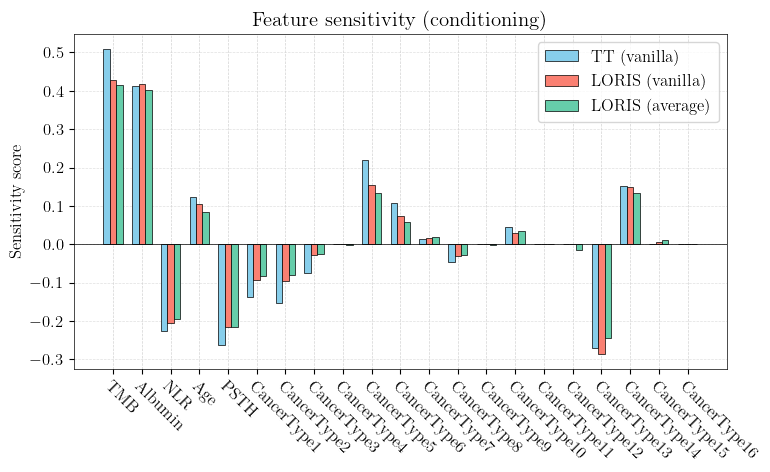

In [166]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (conditioning)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_cond.pdf'),
            bbox_inches='tight')
plt.show()

Marginalizing variables

In [167]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))

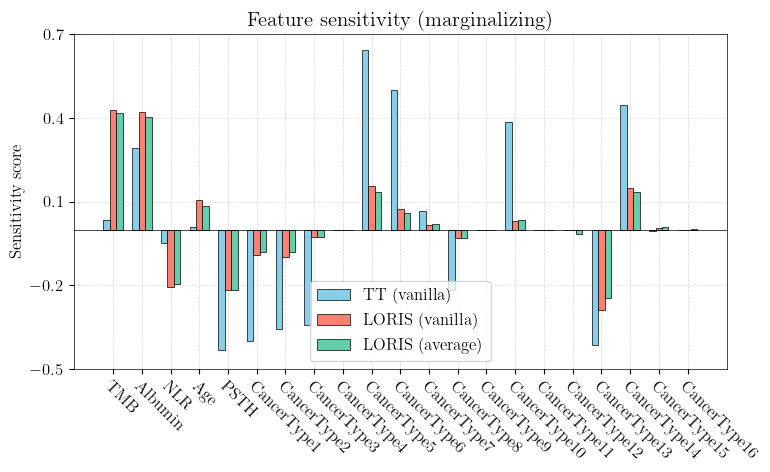

In [168]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (marginalizing)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='lower center')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.3)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_marg.pdf'),
            bbox_inches='tight')
plt.show()

Recovering LR coefficiets from the TT

In [169]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_coeffs(feat, lr_van_model, xt_train,
                                                    featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_coeffs(feat, lr_avg_model, xt_train,
                                                    featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_coeffs(feat, tt_model, xt_train,
                                                featuresNA, scalers_train))

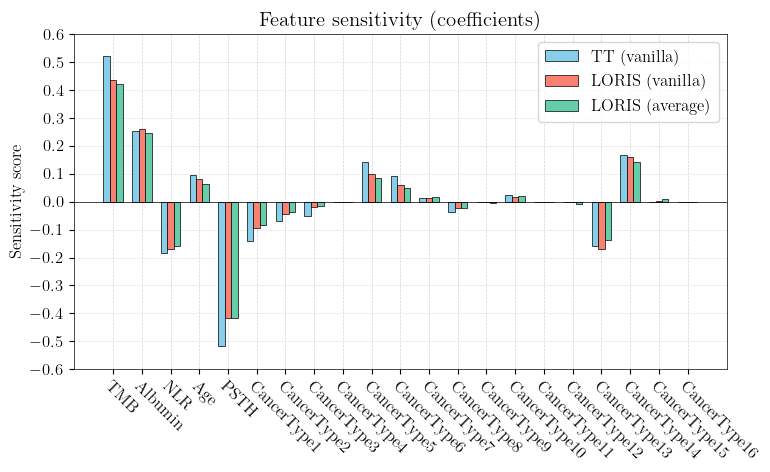

In [170]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
            bbox_inches='tight')
plt.show()

## Monotonic plots

In [171]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'MinMax'
scaler_type = 'Standard'

dataset = ['Chowell_train'] # 'MSK1', 'MSK2'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

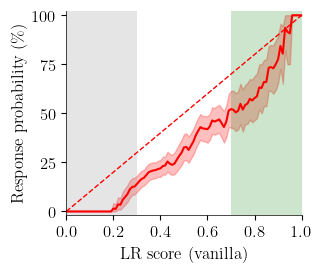

In [172]:
response_curve(lr_van_model, xt_train, yt_train, xlabel='LR score (vanilla)')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_van.pdf'),
            bbox_inches='tight')
plt.show()

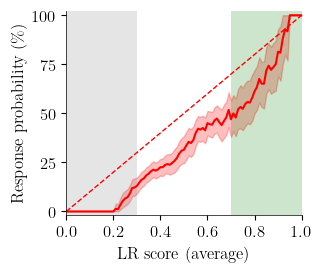

In [173]:
response_curve(lr_avg_model, xt_train, yt_train, xlabel='LR score (average)')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_avg.pdf'),
            bbox_inches='tight')
plt.show()

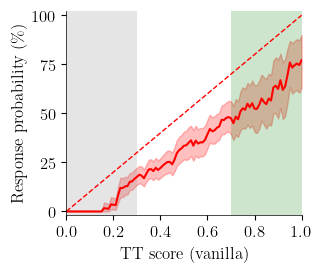

In [174]:
response_curve(tt_model, xt_train, yt_train, xlabel='TT score (vanilla)')

plt.savefig(os.path.join(figures_dir, 'monotonic_tt.pdf'),
            bbox_inches='tight')
plt.show()